# Figure3

In [2]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import matplotlib.colors as mcolors
from matplotlib import rcParams, rcParamsDefault
from matplotlib.lines import Line2D
from src.utils.tools import seed_everything
import matplotlib.patches as mpatches

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 500,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}


# Figure 3B

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


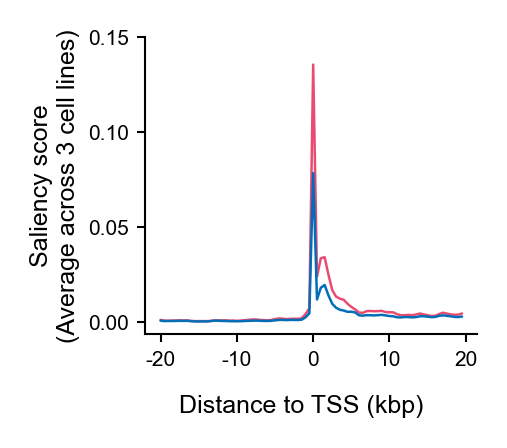

In [10]:
fig, ax =plt.subplots(1,1,constrained_layout=True, figsize=(4/2.54, 3.5/2.54))
palette = ['#E94C72','#036EB8']

eid = 'E003'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1_E003 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2_E003 =  np.load(f)


eid = 'E116'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1_E116 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2_E116 =  np.load(f)


eid = 'E118'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1_E118 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2_E118 =  np.load(f)



distribution1 = (distribution1_E003 + distribution1_E116 + distribution1_E118) / 3
distribution2 = (distribution2_E003 + distribution2_E116 + distribution2_E118) / 3

sns.lineplot(distribution1,color=palette[0], linewidth=0.6,ax=ax)
sns.lineplot(distribution2,color=palette[1], linewidth=0.6,ax=ax)


ax.legend().remove()
ax.set_xticks([i for i in range(0,81,20)])
ax.set_yticks([i/100 for i in range(0,16,5)])
xticklabels = [int((i-40)/2) for i in range(0,81,20)]
ax.set_xticklabels(xticklabels)
ax.tick_params(axis='both', labelsize=5,width=0.5)
ax.set_ylabel(f"Saliency score\n(Average across 3 cell lines)",ha='center')
# ax.set_title('7 marks')
fig.supxlabel(f"Distance to TSS (kbp)",x=0.6,fontsize=6)

import matplotlib.lines as mlines
legend_lines = [
    mlines.Line2D([], [], color=palette[0], linestyle="-", label='BF'),
    mlines.Line2D([], [], color=palette[1], linestyle="-", label='BS'),

]
# legend = fig.legend(handles=legend_lines, title= '', loc='upper left', bbox_to_anchor=(0.98, 1.02), title_fontsize=6,fontsize=5,ncol=1,edgecolor='none',handlelength=2/2.54 ,columnspacing=1.5)


plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Figure3A.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 3B

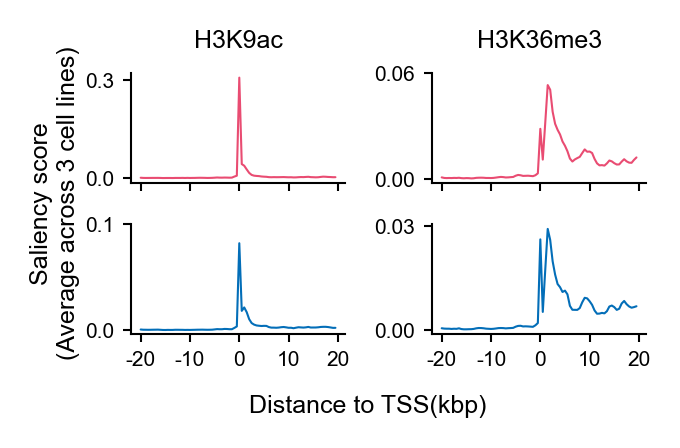

In [12]:
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
# yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
yticks = [ 'H3K9ac','H3K36me3']
idxes = [MARKS.index(mark) for mark in yticks]
palette = ['#E94C72','#036EB8']

eid = 'E003'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E003 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E003 =  np.load(f)


eid = 'E116'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E116 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E116 =  np.load(f)


eid = 'E118'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E118 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E118 =  np.load(f)



attributions1 = (attributions1_E003 + attributions1_E116 + attributions1_E118) / 3
attributions2 = (attributions2_E003 + attributions2_E116 + attributions2_E118) / 3
attributions1 = attributions1[idxes]
attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 2, constrained_layout=True, figsize=(5/2.54, 3.5/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, mark in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=mark,ax=ax[0,_idx],color = palette[0],linewidth=0.5)
   ax[0,_idx].legend().remove()
   ax[0,_idx].tick_params(axis='both', labelsize=5, width=0.5)
   xticklabels = [int((i - 40) / 2) for i in range(0, 81, 20)]
   ax[0,_idx].set_xticks(np.arange(0, 81,20),labels='')
   ax[0,_idx].set_xlabel(f"", fontsize=6,ha='center')
   ax[0,_idx].set_title(mark)


for _idx, mark in enumerate(yticks):
   sns.lineplot(attributions2[_idx],label=mark,ax=ax[1,_idx],color = palette[1],linewidth=0.5)
   ax[1,_idx].legend().remove()
   ax[1,_idx].tick_params(axis='both', labelsize=5, width=0.5)
   xticklabels = [int((i - 40) / 2) for i in range(0, 81, 20)]
   ax[1,_idx].set_xticks(np.arange(0, 81,20),labels=xticklabels)
   ax[1,_idx].set_xlabel(f"", fontsize=6,ha='center')
   # if _idx == 0:
   #    ax[1,_idx].set_ylabel("Size")

fig.supxlabel(f"Distance to TSS(kbp)", fontsize=6,x=0.5)
fig.supylabel(f"Saliency score\n(Average across 3 cell lines)", fontsize=6,x=-0.03,y=0.55,ha='center')

ax[0,0].set_yticks([i/10 for i in range(0,4,3)])
ax[0,1].set_yticks([i/100 for i in range(0,7,6)])
ax[1,0].set_yticks([i/10 for i in range(0,2,1)])
ax[1,1].set_yticks([i/100 for i in range(0,4,3)])


import matplotlib.lines as mlines
legend_lines = [
    mlines.Line2D([], [], color=palette[0], linestyle="-", label='BF'),
    mlines.Line2D([], [], color=palette[1], linestyle="-", label='BS'),

]

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Figure3B.eps', format='eps', bbox_inches='tight')

plt.show()

# Figure 3C

  keep_mark  fold  increase
0   H3K27ac     0  0.007198
1   H3K27ac     1  0.011291
2   H3K27ac     2  0.010334
3   H3K27ac     3  0.006565
4  H3K27me3     0  0.177628
5  H3K27me3     1  0.179696
6  H3K27me3     2  0.198105
7  H3K27me3     3  0.198131
8  H3K36me3     0  0.565754
9  H3K36me3     1  0.536556
  keep_mark  fold  increase
0   H3K27ac     0  0.023594
1   H3K27ac     1  0.017549
2   H3K27ac     2  0.017902
3   H3K27ac     3  0.015180
4  H3K27me3     0  0.074803
5  H3K27me3     1  0.072722
6  H3K27me3     2  0.077461
7  H3K27me3     3  0.072931
8  H3K36me3     0  0.253895
9  H3K36me3     1  0.266924


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_65392/3634606913.py:35: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=1)


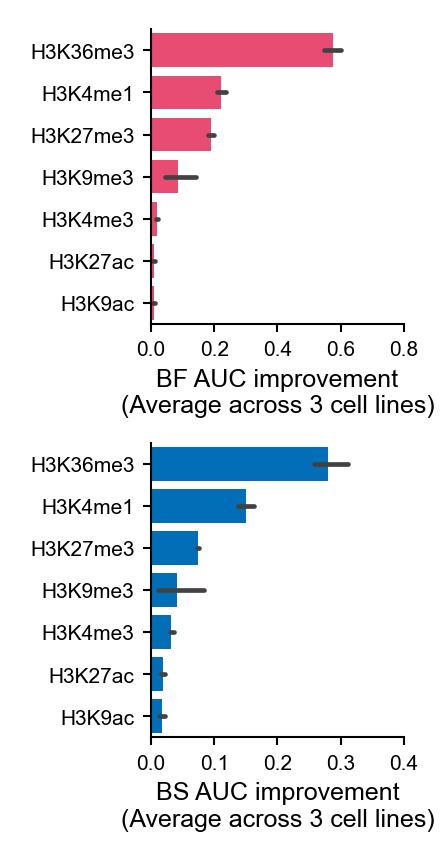

In [5]:
fig, ax = plt.subplots(2,1, constrained_layout=True, figsize=(3.5/2.54, 7/2.54))
palette = ['#E94C72','#036EB8']
target = 'bf'
data_1 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target}_para.csv')
data_2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_distance_1000_{target}_para.csv')
data = pd.merge(data_1,data_2,on=['eid','keep_mark','fold'])
data['increase'] = data['auc_x']/data['auc_y'] - 1
data = data[['keep_mark','fold','increase']].groupby(by=['keep_mark','fold'],as_index=False).agg('mean')
print(data.head(10))
order = pd.Index(["H3K36me3","H3K4me1","H3K27me3","H3K9me3","H3K4me3","H3K27ac","H3K9ac"],name='marks')
sns.barplot(data=data,x='increase',y='keep_mark',order=order,ax=ax[0],color=palette[0],saturation=1,linewidth=0)

ax[0].set_xticks([i/10 for i in range(0,9,2)])
ax[0].set_ylabel('',fontsize=6)
ax[0].set_xlabel('BF AUC improvement\n(Average across 3 cell lines)')
ax[0].tick_params(axis='both', labelsize=5,width=0.5)


target = 'bs'
data_1 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_{target}_para.csv')
data_2 = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_distance_1000_{target}_para.csv')
data = pd.merge(data_1,data_2,on=['eid','keep_mark','fold'])
data['increase'] = data['auc_x']/data['auc_y'] - 1
data = data[['keep_mark','fold','increase']].groupby(by=['keep_mark','fold'],as_index=False).agg('mean')
print(data.head(10))
order = pd.Index(["H3K36me3","H3K4me1","H3K27me3","H3K9me3","H3K4me3","H3K27ac","H3K9ac"],name='marks')
sns.barplot(data=data,x='increase',y='keep_mark',order=order,ax=ax[1],color=palette[1],saturation=1,linewidth=0)

# ax[1].set_title('Burst size',fontsize=6,fontweight='regular')

ax[1].set_ylabel('',fontsize=6)
ax[1].set_xticks([i/10 for i in range(5)])
ax[1].set_xlabel('BS AUC improvement\n(Average across 3 cell lines)')
ax[1].tick_params(axis='both', labelsize=5,width=0.5)
fig.subplots_adjust(hspace=1)
# fig.supxlabel('Average AUC improvement across 3 cell lines',fontsize=6,fontweight='regular')
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Figure3B.eps', format='eps', bbox_inches='tight')

plt.show()


# Figure 3D

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_75821/1273312206.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['BF-', 'BF+'])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_75821/1273312206.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['BS-', 'BS+'])


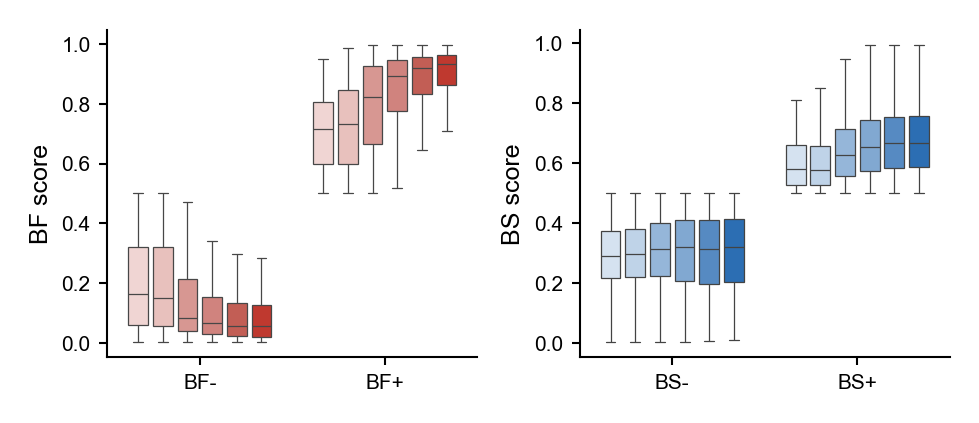

In [40]:
fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(6/2.54, 3.5/2.54))

data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv')

palette = {
    1000: '#F0D5D3',
    2000: '#E8C1BD',
    5000: '#D79792',
    10000: '#D0837E',
    20000: '#C25E55',
    40000: '#BF392F'
}

sns.boxplot(data=data,
            x='bf_label_pred',
            y='bf_label_score',
            hue='window_size',
            palette=palette,
            fliersize=0,
            linewidth=0.3,
            width=0.8,
            gap=0.2,
            ax=ax[0],
            saturation=1,
            )


palette = {
    1000: '#D5E2F0',
    2000: '#BFD3E8',
    5000: '#95B6D9',
    10000: '#81A8D1',
    20000: '#568AC2',
    40000: '#2C6EB3'
}

sns.boxplot(data=data,
            x='bs_label_pred',
            y='bs_label_score',
            hue='window_size',
            palette=palette,
            fliersize=0,
            linewidth=0.3,   
            width=0.8, 
            gap=0.2,        
            ax=ax[1],
            saturation=1,
            )

handles, labels = ax[0].get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]
ax[0].legend().remove()
ax[0].set_ylabel('BF score')
ax[0].set_xlabel('')
ax[0].set_xticklabels(['BF-', 'BF+'])
# ax[0].set_title('')


ax[1].legend().remove()
ax[1].set_ylabel('BS score')
ax[1].set_xlabel('')
ax[1].set_xticklabels(['BS-', 'BS+'])
fig.supxlabel('')
# fig.supxlabel('Label',x=0.55,y=-0.05)
# legend = fig.legend(handles, labels, title= 'Region Surrounding\nTSS (kbp)', loc='upper left', bbox_to_anchor=(0.98, 1.02), title_fontsize=6,fontsize=5,ncol=1,edgecolor='none',handlelength=1.3 ,columnspacing=1.5)
# plt.setp(legend.get_title(), horizontalalignment='center')
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure3D.eps', format='eps', bbox_inches='tight')
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9004/4007971990.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9004/4007971990.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


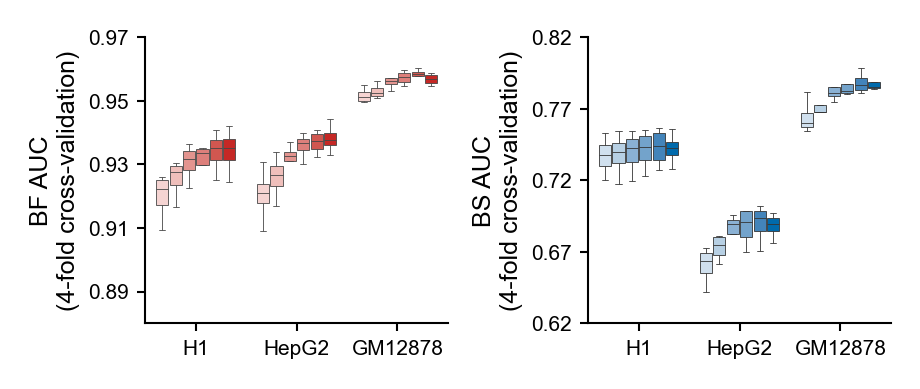

In [3]:
import matplotlib.colors as mcolors

target = 'bs'
data_bs = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/distance_{target}_para.csv',sep='\t')
data_bs['auc'] = data_bs['auc'] / 100
target = 'bf'
data_bf = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/distance_{target}_para.csv',sep='\t')
data_bf['auc'] = data_bf['auc'] / 100

fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(7.5/2.54, 3/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')



# palette = ['#F2D7D5','#ECC4C0','#DF9C96','#DD8E89','#CC6158','#BF392F']
palette = ['#F5D4D2','#EFBFBB','#E3948F','#DD7F7B','#D05750','#C52825']

sns.boxplot(data=data_bf,x='eid',y='auc',hue='distance',ax=ax[0],order=order,linewidth=0.2,fliersize=0,
             gap=0.1,width=0.8,palette=palette,saturation=1)

# palette = ['#D5E2F0','#BFD3E8','#95B6D9','#81A8D1','#568AC2','#2C6EB3']
palette = ['#D0E0EE','#B7D0E4','#8AB1D4','#73A3CB','#4384BA','#006AAC']
sns.boxplot(data=data_bs,x='eid',y='auc',hue='distance',ax=ax[1],order=order,linewidth=0.2,fliersize=0,
            gap=0.1,width=0.8, palette=palette,saturation=1)


ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].set_ylim(bottom=0.88,top=0.97)
ax[0].set_xlabel('')
ax[0].set_ylabel(f'BF AUC\n(4-fold cross-validation)',fontsize=6)
ax[0].legend().remove()
# ax[0].set_title('Burst frequency',fontsize=6,fontweight='regular')
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_yticks([i/100 for i in range(89, 98, 2)],labels=[i/100 for i in range(89, 98, 2)])


ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_ylabel(f'BS AUC\n(4-fold cross-validation)',fontsize=6)
ax[1].set_ylim(bottom=0.62,top=0.80)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
# ax[1].set_title('Burst size',fontsize=6,fontweight='regular')
ax[1].set_yticks([i/100 for i in range(62, 84, 5)],labels=[i/100 for i in range(62, 84, 5)])


handles, labels = ax[0].get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]
# fig.legend(handles, labels, title= 'Receptive field(kbp)', loc='upper left', bbox_to_anchor=(0.98, 1.02), title_fontsize=6,fontsize=5,ncol=1,edgecolor='none',handlelength=1.3 ,columnspacing=1.5)
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4D.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 3E

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


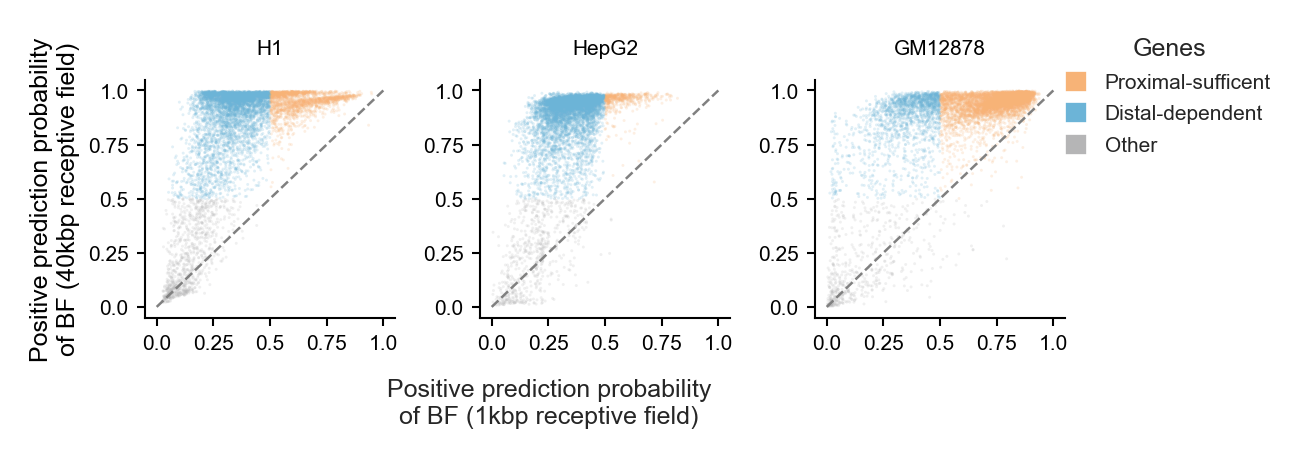

In [33]:
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")



palette = ["#F7B377","#6CB4D7"]
palette = ["#F7B377","#6CB4D7",'#B5B5B6','#B5B5B6']

def _func(row):
    if row['bf_label_pred_x']==1 and row['bf_label_pred_y']==1:
        return 'c1'
    elif row['bf_label_pred_x']==0 and row['bf_label_pred_y']==1:
        return 'c2'
    elif row['bf_label_pred_x']==1 and row['bf_label_pred_y']==0:
        return 'c3'
    else:
        return 'c4'
    

fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(9/2.54, 3.5/2.54))

eid = 'E003'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')
data_merge['bin'] = data_merge.apply(lambda row: _func(row),axis=1)

hue_order = ['c1','c2','c3','c4']
sns.scatterplot(data=data_merge[data_merge['bin'].isin(['c1','c2','c3','c4'])],x='bf_label_score_x',y='bf_label_score_y',hue='bin',hue_order=hue_order,s=0.5,alpha=0.2,palette=palette,edgecolors='none',ax=ax[0])
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[0])
ax[0].set_xticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[0].set_yticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[0].set_xlabel('',fontsize=6)
ax[0].set_ylabel('Positive prediction probability\nof BF (40kbp receptive field)',fontsize=6)
ax[0].legend().remove()
ax[0].set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=5)


eid = 'E118'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')
data_merge['bin'] = data_merge.apply(lambda row: _func(row),axis=1)

hue_order = ['c1','c2','c3','c4']
sns.scatterplot(data=data_merge[data_merge['bin'].isin(['c1','c2','c3','c4'])],x='bf_label_score_x',y='bf_label_score_y',hue='bin',hue_order=hue_order,s=0.5,alpha=0.2,palette=palette,edgecolors='none',ax=ax[1])
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6,ax=ax[1])
ax[1].set_xticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[1].set_yticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[1].set_xlabel('',fontsize=6)
ax[1].set_ylabel('',fontsize=6)
ax[1].legend().remove()
ax[1].set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=5)


eid = 'E116'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')
data_merge['bin'] = data_merge.apply(lambda row: _func(row),axis=1)

hue_order = ['c1','c2','c3','c4']
sns.scatterplot(data=data_merge[data_merge['bin'].isin(['c1','c2','c3','c4'])],x='bf_label_score_x',y='bf_label_score_y',hue='bin',hue_order=hue_order,s=0.5,alpha=0.2,palette=palette,edgecolors='none',ax=ax[2])
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6,ax=ax[2])
ax[2].set_xticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[2].set_yticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[2].set_xlabel('',fontsize=6)
ax[2].set_ylabel('',fontsize=6)
ax[2].legend().remove()
ax[2].set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=5)


fig.supxlabel('Positive prediction probability\nof BF (1kbp receptive field)')
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='Proximal-sufficent'),
    mpatches.Patch(color=palette[1], label='Distal-dependent'),
    mpatches.Patch(color=palette[2], label='Other'),
]

fig.legend(
    handles=legend_patches,
    title="Genes", 
    loc="upper left", 
    bbox_to_anchor=(0.97, 1.02), 
    title_fontsize=6,
    fontsize=5, 
    ncol=1,
    edgecolor='none', 
    handleheight=2/2.54, 
    handlelength=2/2.54,
    handletextpad=1.0,
    labelspacing=1.5/2.54
)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Figure3E.eps', format='eps', bbox_inches='tight')

plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78913/662764805.py:128: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Figure3E.eps', format='eps', bbox_inches='tight')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


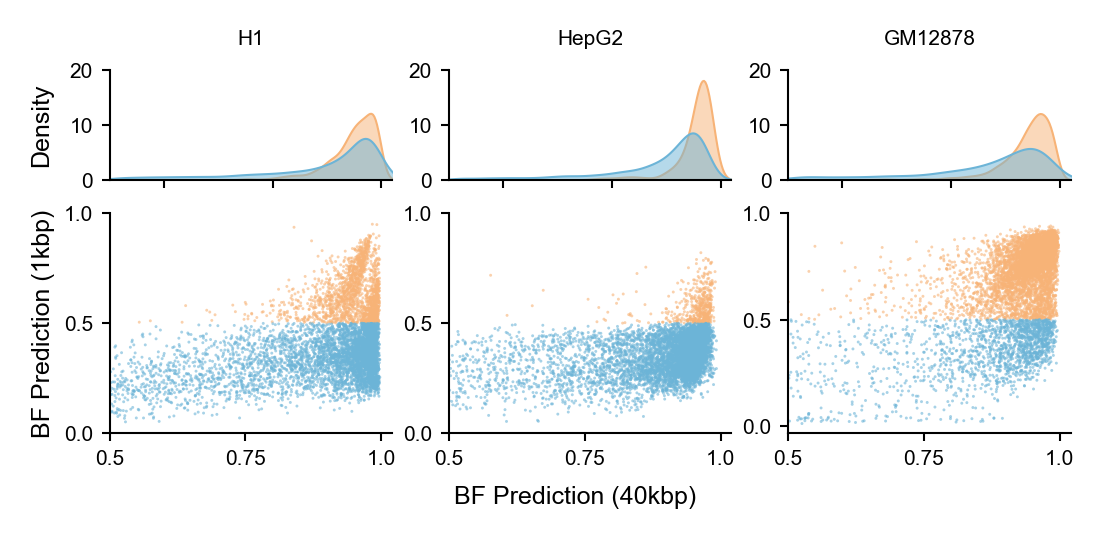

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec


fig = plt.figure(constrained_layout=True,figsize=(10.5/2.54, 4/2.54))
gs = gridspec.GridSpec(2, 3,width_ratios=[1, 1, 1], height_ratios=[1, 2])

# 散点图

data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")

palette = ["#F7B377","#6CB4D7"]
# palette = ["#F7B377","#6CB4D7",'#B5B5B6','#B5B5B6']


eid = 'E003'
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")
data = data[(data['eid']==eid) & (data['bf_label_label']==1)]
gene_ids_1kbp = list(data[(data['window_size']==1000) & (data['bf_label_pred']==1)]['gene_id'])
gene_ids_40kbp = list(data[(data['window_size']==40000) & (data['bf_label_pred']==1)]['gene_id'])
short_range_gene_ids = [gene_id for gene_id in gene_ids_40kbp if gene_id in gene_ids_1kbp]
long_range_gene_ids = [gene_id for gene_id in gene_ids_40kbp if gene_id not in gene_ids_1kbp]

ax = plt.subplot(gs[1, 0])
x = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
y = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==1000)]['bf_label_score'])
sns.scatterplot(x=x, y=y, color=palette[0], alpha=0.6, label='Category 1', s=0.5, ax=ax,edgecolors='none')

x = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
y = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==1000)]['bf_label_score'])
sns.scatterplot(x=x, y=y, color=palette[1], alpha=0.6, label='Category 1', s=0.5, ax=ax,edgecolors='none')
ax.legend().remove()
ax.set_ylabel('BF Prediction (1kbp)')
ax.set_xlim(0.5,1.02)
ax.set_xticks([i/100 for i in range(50, 101, 25)],labels=[i/100 for i in range(50, 101, 25)])
ax.set_yticks([i/100 for i in range(0, 101, 50)],labels=[i/100 for i in range(0, 101, 50)])
# 类别1的KDE密度图
ax_top = plt.subplot(gs[0, 0])
short_range_gene_scores = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
long_range_gene_scores = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
sns.kdeplot(x=short_range_gene_scores, ax=ax_top, color=palette[0], fill=True, alpha=0.5, linewidth=0.5)
sns.kdeplot(x=long_range_gene_scores, ax=ax_top, color=palette[1], fill=True, alpha=0.5, linewidth=0.5)
ax_top.set_xlim(0.5,1.02)
ax_top.set_xticklabels([])
ax_top.set_ylabel('Density')
ax_top.yaxis.set_label_coords(-0.2, 0.5)  # x 越小越靠左，y=0.5 为垂直居中
ax_top.yaxis.set_label_position("left")
ax_top.yaxis.tick_left()
ax_top.set_ylim(0,20)
ax_top.set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=5)



eid = 'E118'
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")
data = data[(data['eid']==eid) & (data['bf_label_label']==1)]
gene_ids_1kbp = list(data[(data['window_size']==1000) & (data['bf_label_pred']==1)]['gene_id'])
gene_ids_40kbp = list(data[(data['window_size']==40000) & (data['bf_label_pred']==1)]['gene_id'])
short_range_gene_ids = [gene_id for gene_id in gene_ids_40kbp if gene_id in gene_ids_1kbp]
long_range_gene_ids = [gene_id for gene_id in gene_ids_40kbp if gene_id not in gene_ids_1kbp]

ax = plt.subplot(gs[1, 1])
x = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
y = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==1000)]['bf_label_score'])
sns.scatterplot(x=x, y=y, color=palette[0], alpha=0.6, label='Category 1', s=0.5, ax=ax,edgecolors='none')

x = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
y = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==1000)]['bf_label_score'])
sns.scatterplot(x=x, y=y, color=palette[1], alpha=0.6, label='Category 1', s=0.5, ax=ax,edgecolors='none')
ax.legend().remove()
ax.set_xlim(0.5,1.02)
ax.set_xticks([i/100 for i in range(50, 101, 25)],labels=[i/100 for i in range(50, 101, 25)])
ax.set_yticks([i/100 for i in range(0, 101, 50)],labels=[i/100 for i in range(0, 101, 50)])
# 类别1的KDE密度图
ax_top = plt.subplot(gs[0, 1])
short_range_gene_scores = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
long_range_gene_scores = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
sns.kdeplot(x=short_range_gene_scores, ax=ax_top, color=palette[0], fill=True, alpha=0.5, linewidth=0.5)
sns.kdeplot(x=long_range_gene_scores, ax=ax_top, color=palette[1], fill=True, alpha=0.5, linewidth=0.5)
ax_top.set_xlim(0.5,1.02)
ax_top.set_xticklabels([])
ax_top.set_ylabel('')
ax_top.yaxis.set_label_position("left")
ax_top.yaxis.tick_left()
ax_top.set_ylim(0,20)
ax_top.set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=5)



eid = 'E116'
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")
data = data[(data['eid']==eid) & (data['bf_label_label']==1)]
gene_ids_1kbp = list(data[(data['window_size']==1000) & (data['bf_label_pred']==1)]['gene_id'])
gene_ids_40kbp = list(data[(data['window_size']==40000) & (data['bf_label_pred']==1)]['gene_id'])
short_range_gene_ids = [gene_id for gene_id in gene_ids_40kbp if gene_id in gene_ids_1kbp]
long_range_gene_ids = [gene_id for gene_id in gene_ids_40kbp if gene_id not in gene_ids_1kbp]

ax = plt.subplot(gs[1, 2])
x = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
y = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==1000)]['bf_label_score'])
sns.scatterplot(x=x, y=y, color=palette[0], alpha=0.6, label='Category 1', s=0.5, ax=ax,edgecolors='none')

x = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
y = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==1000)]['bf_label_score'])
sns.scatterplot(x=x, y=y, color=palette[1], alpha=0.6, label='Category 1', s=0.5, ax=ax,edgecolors='none')
ax.legend().remove()
ax.set_xlim(0.5,1.02)
ax.set_xticks([i/100 for i in range(50, 101, 25)],labels=[i/100 for i in range(50, 101, 25)])
ax.set_yticks([i/100 for i in range(0, 101, 50)],labels=[i/100 for i in range(0, 101, 50)])
# 类别1的KDE密度图
ax_top = plt.subplot(gs[0, 2])
short_range_gene_scores = list(data[data['gene_id'].isin(short_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
long_range_gene_scores = list(data[data['gene_id'].isin(long_range_gene_ids) & (data['window_size']==40000)]['bf_label_score'])
sns.kdeplot(x=short_range_gene_scores, ax=ax_top, color=palette[0], fill=True, alpha=0.5, linewidth=0.5)
sns.kdeplot(x=long_range_gene_scores, ax=ax_top, color=palette[1], fill=True, alpha=0.5, linewidth=0.5)
ax_top.set_xlim(0.5,1.02)
ax_top.set_xticklabels([])
ax_top.set_ylabel('')
ax_top.yaxis.set_label_position("left")
ax_top.yaxis.tick_left()
ax_top.set_ylim(0,20)
ax_top.set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=5)
# # 调整布局
fig.supxlabel('BF Prediction (40kbp)',y=-0.05)
# plt.subplots_adjust(hspace=0.2)

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Figure3E.eps', format='eps', bbox_inches='tight')

plt.show()

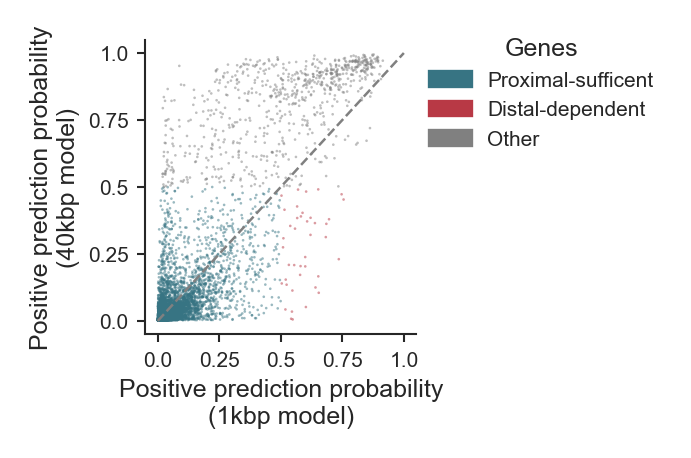

In [20]:
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")
eid = 'E116'

data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==0)]


data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==0)]


data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')

    
def _func(row):
    if row['bf_label_pred_x']==0 and row['bf_label_pred_y']==0:
        return 'c1'
    elif row['bf_label_pred_x']==1 and row['bf_label_pred_y']==0:
        return 'c2'
    elif row['bf_label_pred_x']==0 and row['bf_label_pred_y']==1:
        return 'c3'
    else:
        return 'c4'

data_merge['bin'] = data_merge.apply(lambda row: _func(row),axis=1)
# data_merge.groupby(by='bin').count()

palette = ["#377483","#B83945",'gray','gray']
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(3.5/2.54, 3.5/2.54))
hue_order = ['c1','c2','c3','c4']
sns.scatterplot(data=data_merge[data_merge['bin'].isin(['c1','c2','c3','c4'])],x='bf_label_score_x',y='bf_label_score_y',hue='bin',hue_order=hue_order,s=0.4,alpha=0.5,palette=palette,edgecolors='none')
sns.lineplot(x=[0, 1], y=[0, 1], ax=ax, color='gray', linestyle='--', linewidth=0.6)


ax.set_xticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax.set_yticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])

ax.set_xlabel('Positive prediction probability\n(1kbp model)',fontsize=6)
ax.set_ylabel('Positive prediction probability\n(40kbp model)',fontsize=6)

ax.legend().remove()

import matplotlib.lines as mlines
legend_patches = [
    mpatches.Patch(color=palette[0], label='Proximal-sufficent'),
    mpatches.Patch(color=palette[1], label='Distal-dependent'),
    mpatches.Patch(color=palette[2], label='Other'),
]

fig.legend(handles=legend_patches, title="Genes", loc="upper left", bbox_to_anchor=(0.95, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')
# plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Figure3E.eps', format='eps', bbox_inches='tight')

plt.show()

# Figure 3F

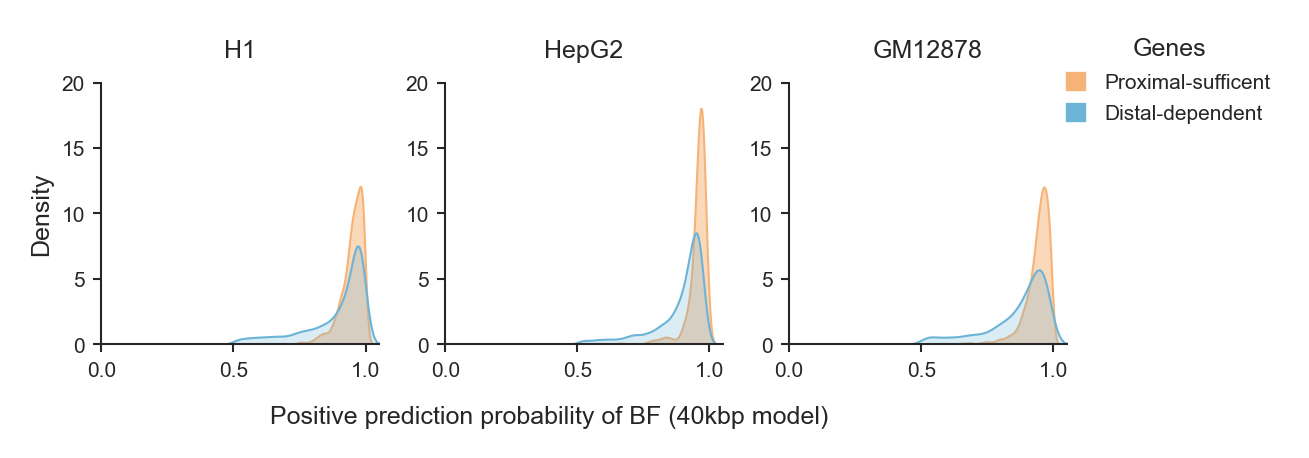

In [41]:
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")
palette = ["#F7B377","#6CB4D7"]

fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(9/2.54, 3.5/2.54))

eid = 'E003'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]

sns.kdeplot(data_40kb[data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5,alpha=0.5, color=palette[0],ax=ax[0])
sns.kdeplot(data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5, color=palette[1],ax=ax[0])

ax[0].set_xlabel('',fontsize=6)
ax[0].set_ylabel('Density',fontsize=6)
ax[0].set_yticks([i for i in range(0,21,5)])
ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[0].set_xlim(0,1.05)
ax[0].set_title(f"{EIDS_TO_CELLTYPES[eid]}")

eid = 'E118'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]

sns.kdeplot(data_40kb[data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5,alpha=0.5, color=palette[0],ax=ax[1])
sns.kdeplot(data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5, color=palette[1],ax=ax[1])

ax[1].set_xlabel('',fontsize=6)
ax[1].set_ylabel('',fontsize=6)
ax[1].set_yticks([i for i in range(0,21,5)])
ax[1].set_xticks([i/10 for i in range(0,11,5)])
ax[1].set_xlim(0,1.05)
ax[1].set_title(f"{EIDS_TO_CELLTYPES[eid]}")



eid = 'E116'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]

sns.kdeplot(data_40kb[data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5,alpha=0.5, color=palette[0],ax=ax[2])
sns.kdeplot(data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5, color=palette[1],ax=ax[2])

ax[2].set_xlabel('',fontsize=6)
ax[2].set_ylabel('',fontsize=6)
ax[2].set_yticks([i for i in range(0,21,5)])
ax[2].set_xticks([i/10 for i in range(0,11,5)])
ax[2].set_xlim(0,1.05)
ax[2].set_title(f"{EIDS_TO_CELLTYPES[eid]}")

fig.supxlabel('Positive prediction probability of BF (40kbp model)')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='Proximal-sufficent'),
    mpatches.Patch(color=palette[1], label='Distal-dependent'),
]
fig.legend(
    handles=legend_patches, 
    title="Genes", 
    loc="upper left", 
    bbox_to_anchor=(0.97, 1.02), 
    title_fontsize=6,
    fontsize=5, 
    ncol=1,
    edgecolor='none', 
    handleheight=2/2.54, 
    handlelength=2/2.54,
    handletextpad=1.0,
    labelspacing=1.5/2.54
)

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Figure3F.svg', format='svg', bbox_inches='tight')


plt.show()


# Figure 3G

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_51237/3433041676.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


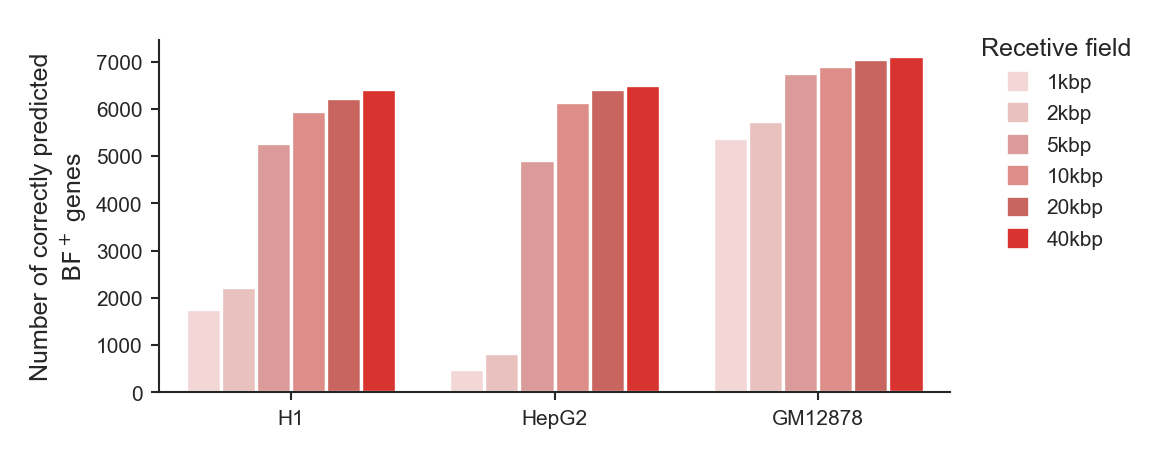

In [40]:
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")


data = data[ (data['bf_label_label']==1) & (data['bf_label_label']==data['bf_label_pred'])]

data = data[['window_size','eid','gene_id']].groupby(by=['eid','window_size'],as_index=False).agg('count')
data.to_csv('extra/datasets/benchmark/Promoterformer/results/gene_counts_across_3_celllines.csv',index=False)

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(8/2.54, 3.5/2.54))
palette = ['#F2D7D6','#E9C2C0','#DB9B98','#DD8E89','#C7655E','#D93330']

order = ['E003','E118','E116']
hue_order = [1000,2000,5000,10000,20000,40000]

sns.barplot(data=data,x='eid',y='gene_id',hue='window_size',hue_order=hue_order,order=order,palette=palette,saturation=1)

handles, labels = ax.get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]
ax.legend().remove()
ax.set_ylabel('Number of correctly predicted\n$\mathrm{BF}^+$ genes')
ax.set_xlabel('')
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)


import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='1kbp'),
    mpatches.Patch(color=palette[1], label='2kbp'),
    mpatches.Patch(color=palette[2], label='5kbp'),
    mpatches.Patch(color=palette[3], label='10kbp'),
    mpatches.Patch(color=palette[4], label='20kbp'),
    mpatches.Patch(color=palette[5], label='40kbp'),
]
fig.legend(
    handles=legend_patches, 
    title="Recetive field", 
    loc="upper left", 
    bbox_to_anchor=(1.0, 1.02), 
    title_fontsize=6,
    fontsize=5, 
    ncol=1,
    edgecolor='none', 
    handleheight=2/2.54, 
    handlelength=2/2.54,
    handletextpad=1.0,
    labelspacing=1.5/2.54
)

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Figure3G.eps', format='eps', bbox_inches='tight')

plt.show()

# Supplementary

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


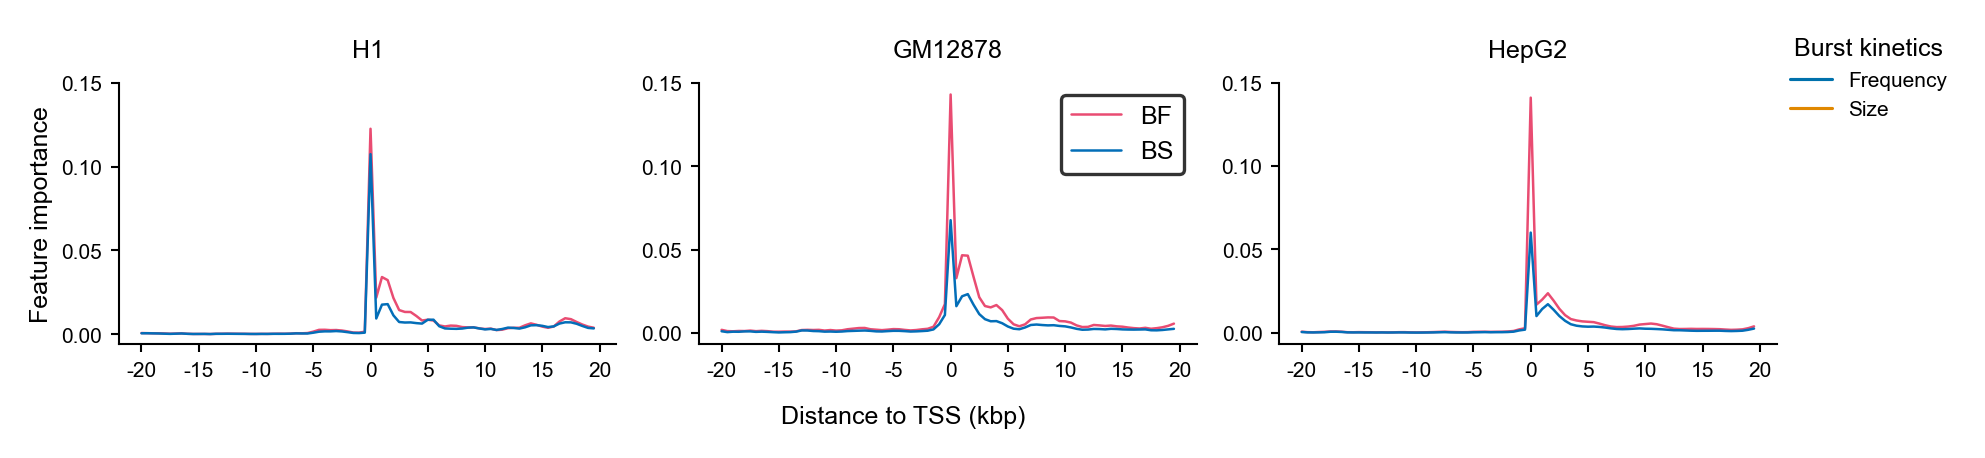

In [4]:
eid = 'E003'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)

# with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_mean_deeplift_distribution.npy','rb') as f:
#    distribution3 =  np.load(f)
palette = ['#E94C72','#036EB8']

fig, ax =plt.subplots(1,3,constrained_layout=True, figsize=(15/2.54, 3.5/2.54))

sns.lineplot(distribution1,color=palette[0], label = 'BF',linewidth=0.6,ax=ax[0])
sns.lineplot(distribution2,color=palette[1], label = 'BS',linewidth=0.6,ax=ax[0])
# sns.lineplot(distribution3,color='blue', label = 'MEAN',linewidth=0.3,ax=ax[0])

# Adjust layout to ensure everything fits
ax[0].legend().remove()
ax[0].set_xticks([i for i in range(0,81,10)])
ax[0].set_yticks([i/100 for i in range(0,16,5)])
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
ax[0].set_xticklabels(xticklabels)
ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].set_ylabel(f"Feature importance",ha='center')
ax[0].set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=6,fontweight='regular')


eid = 'E116'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)


ax[1].legend().remove()
ax[1].set_xticks([i for i in range(0,81,10)])
ax[1].set_yticks([i/100 for i in range(0,16,5)])
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
ax[1].set_xticklabels(xticklabels)
ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_ylabel(f"",ha='center')
ax[1].set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=6,fontweight='regular')

sns.lineplot(distribution1,color=palette[0], label = 'BF',linewidth=0.6,ax=ax[1])
sns.lineplot(distribution2,color=palette[1], label = 'BS',linewidth=0.6,ax=ax[1])

eid = 'E118'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)


sns.lineplot(distribution1,color=palette[0], label = 'BF',linewidth=0.6,ax=ax[2])
sns.lineplot(distribution2,color=palette[1], label = 'BS',linewidth=0.6,ax=ax[2])

ax[2].legend().remove()
ax[2].set_xticks([i for i in range(0,81,10)])
ax[2].set_yticks([i/100 for i in range(0,16,5)])
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
ax[2].set_xticklabels(xticklabels)
ax[2].tick_params(axis='both', labelsize=5,width=0.5)
ax[2].set_ylabel(f"",ha='center')
ax[2].set_title(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=6,fontweight='regular')

fig.supxlabel(f"Distance to TSS (kbp)",ha='center',fontsize=6)

import matplotlib.lines as mlines
legend_lines = [
    mlines.Line2D([], [], color="#0071AC", linestyle="-", label='Frequency'),
    mlines.Line2D([], [], color="#E08800", linestyle="-", label='Size'),

]

fig.legend(handles=legend_lines, title="Burst kinetics",loc="upper left", bbox_to_anchor=(0.99, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

# plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Supplementary_Figure3A.eps', format='eps', bbox_inches='tight')
plt.show()

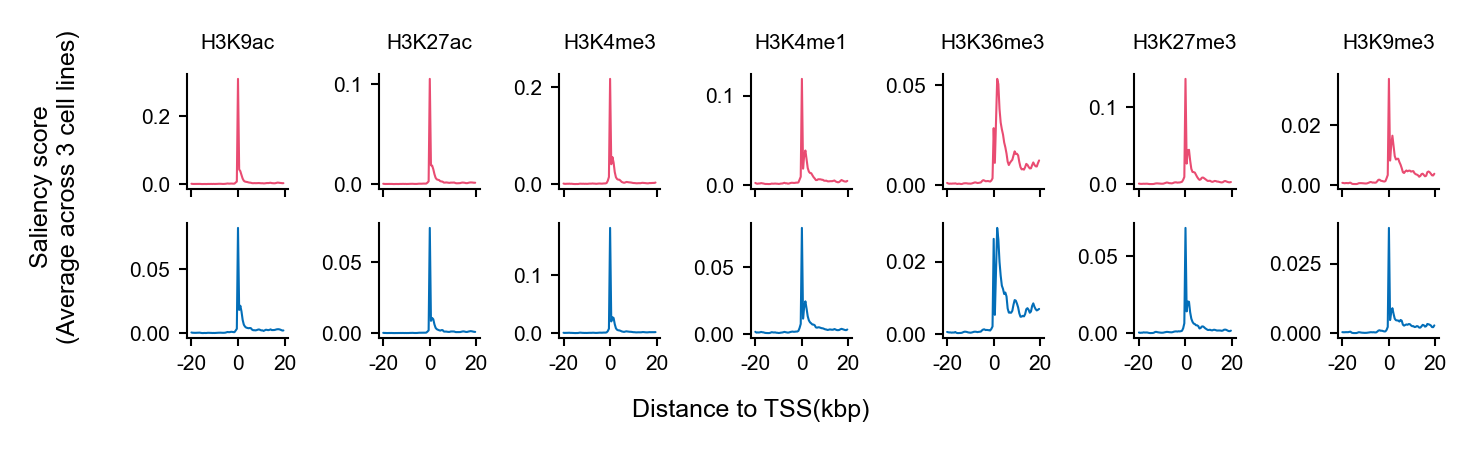

In [9]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]
eid = 'E003'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E003 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E003 =  np.load(f)


eid = 'E116'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E116 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E116 =  np.load(f)




eid = 'E118'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E118 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E118 =  np.load(f)



attributions1 = (attributions1_E003 + attributions1_E116 + attributions1_E118) / 3
attributions2 = (attributions2_E003 + attributions2_E116 + attributions2_E118) / 3
attributions1 = attributions1[idxes]
attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 7, constrained_layout=True, figsize=(12/2.54, 3.5/2.54))
palette = ['#E94C72','#036EB8']
xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,ax=ax[0,_idx],color = palette[0],linewidth=0.5)
   ax[0,_idx].legend().remove()
   ax[0,_idx].tick_params(axis='both', labelsize=5, width=0.5)
   xticklabels = [int((i - 40) / 2) for i in range(0, 41, 20)]
   ax[0,_idx].set_xticks(np.arange(0, 81,40),labels='')
   ax[0,_idx].set_xlabel(f"", fontsize=6,ha='center')


   ax[0,_idx].set_title(ytick, fontsize=5)
   # ax[0,_idx].set_yticks([i/10 for i in range(0,5,2)])
   # ax[0,_idx].set_yticks([i/100 for i in range(0,31,10)])


for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions2[_idx],label=ytick,ax=ax[1,_idx],color = palette[1],linewidth=0.5)
   ax[1,_idx].legend().remove()
   ax[1,_idx].tick_params(axis='both', labelsize=5, width=0.5)
   xticklabels = [int((i - 40) / 2) for i in range(0, 81, 40)]
   ax[1,_idx].set_xticks(np.arange(0, 81,40),labels=xticklabels)
   ax[1,_idx].set_xlabel(f"", fontsize=6,ha='center')
   # ax[1,_idx].set_yticks([i/10 for i in range(0,3,1)])
   # if _idx == 0:
   #    ax[1,_idx].set_ylabel("Size")


# handles, labels = ax[0].get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.supxlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')
fig.supxlabel(f"Distance to TSS(kbp)", fontsize=6)
fig.supylabel(f"Saliency score\n(Average across 3 cell lines)", y=0.6,ha='center')

import matplotlib.lines as mlines
legend_lines = [
    mlines.Line2D([], [], color="#0071AC", linestyle="-", label='Burst frequency'),
    mlines.Line2D([], [], color="#E08800", linestyle="-", label='Burst size'),

]

# fig.legend(handles=legend_lines, title="Burst kinetics",loc="upper left", bbox_to_anchor=(0.99, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')



plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Supplementary_Figure5A.eps', format='eps', bbox_inches='tight')

plt.show()

                gene_id  bs_label_label  bs_label_score  bs_label_pred  \
92878   ENSG00000253797               1        0.525576              1   
92936   ENSG00000204323               1        0.526972              1   
93672   ENSG00000083457               1        0.541100              1   
94595   ENSG00000129226               1        0.542493              1   
94750   ENSG00000109072               1        0.527864              1   
95506   ENSG00000176919               1        0.505796              1   
95620   ENSG00000137073               1        0.549570              1   
95967   ENSG00000137204               1        0.508791              1   
96262   ENSG00000258474               1        0.506068              1   
96999   ENSG00000143627               1        0.501325              1   
97026   ENSG00000139914               1        0.504183              1   
97660   ENSG00000204511               1        0.524205              1   
98083   ENSG00000160789               

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


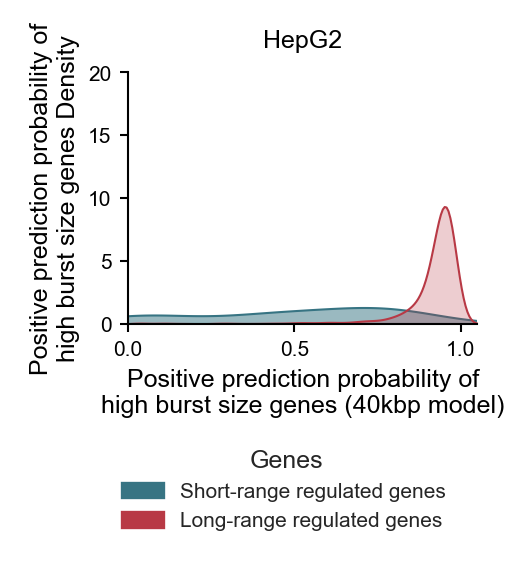

In [31]:
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")
palette = ["#B83945","#377483"]
eid = 'E118'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bs_label_label']==1)]
data_1kb = data_1kb[(data_1kb['bs_label_pred']==data_1kb['bs_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bs_label_label']==1)]
data_40kb = data_40kb[(data_40kb['bs_label_pred']==data_40kb['bs_label_label'])]

# data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')
print(data_1kb)
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(4/2.54, 3.5/2.54))

sns.kdeplot(data_40kb[data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5,alpha=0.5, color=palette[1])
sns.kdeplot(data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5, color=palette[0])

ax.set_xlabel('Positive prediction probability of\nhigh burst size genes (40kbp model)',fontsize=6)
ax.set_ylabel('Positive prediction probability of\nhigh burst size genes Density',fontsize=6)
ax.set_yticks([i for i in range(0,21,5)])
ax.set_xticks([i/10 for i in range(0,11,5)])
ax.set_xlim(0,1.05)

ax.set_title(f'{EIDS_TO_CELLTYPES[eid]}')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[1], label="Short-range regulated genes "),
    mpatches.Patch(color=palette[0], label="Long-range regulated genes"),
]
fig.legend(handles=legend_patches, title="Genes", loc="upper center", bbox_to_anchor=(0.57, -0.0), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Supplementary_figure3B_3.eps', format='eps', bbox_inches='tight')


plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


                gene_id  bs_label_label  bs_label_score  bs_label_pred  \
175645  ENSG00000197020               1        0.735503              1   
175649  ENSG00000176208               1        0.744485              1   
175651  ENSG00000139684               1        0.686421              1   
175653  ENSG00000006695               1        0.734400              1   
175661  ENSG00000184983               1        0.731024              1   
...                 ...             ...             ...            ...   
189621  ENSG00000101365               1        0.529303              1   
189725  ENSG00000115368               1        0.530985              1   
189836  ENSG00000132300               1        0.549612              1   
189888  ENSG00000066422               1        0.494825              0   
190069  ENSG00000085978               0        0.440753              0   

        bf_label_label  bf_label_score  bf_label_pred   eid  fold  window_size  
175645               1        

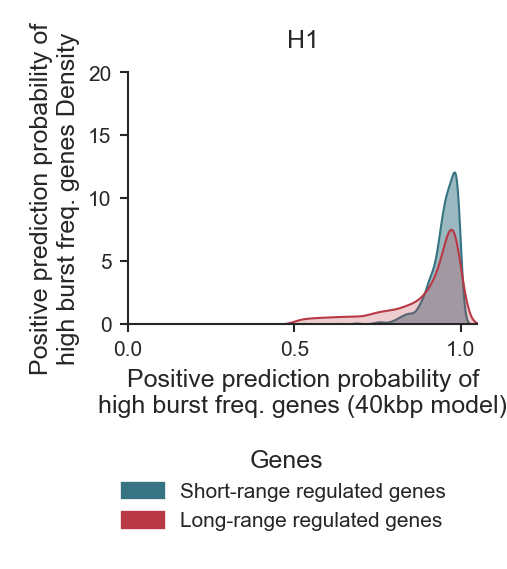

In [13]:
data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")
palette = ["#B83945","#377483"]
eid = 'E003'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]

# data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')
print(data_1kb)
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(4/2.54, 3.5/2.54))

sns.kdeplot(data_40kb[data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5,alpha=0.5, color=palette[1])
sns.kdeplot(data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5, color=palette[0])

ax.set_xlabel('Positive prediction probability of\nhigh burst freq. genes (40kbp model)',fontsize=6)
ax.set_ylabel('Positive prediction probability of\nhigh burst freq. genes Density',fontsize=6)
ax.set_yticks([i for i in range(0,21,5)])
ax.set_xticks([i/10 for i in range(0,11,5)])
ax.set_xlim(0,1.05)

ax.set_title(f'{EIDS_TO_CELLTYPES[eid]}')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[1], label="Short-range regulated genes "),
    mpatches.Patch(color=palette[0], label="Long-range regulated genes"),
]
fig.legend(handles=legend_patches, title="Genes", loc="upper center", bbox_to_anchor=(0.57, -0.0), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Supplementary_figure3A_1.eps', format='eps', bbox_inches='tight')


plt.show()


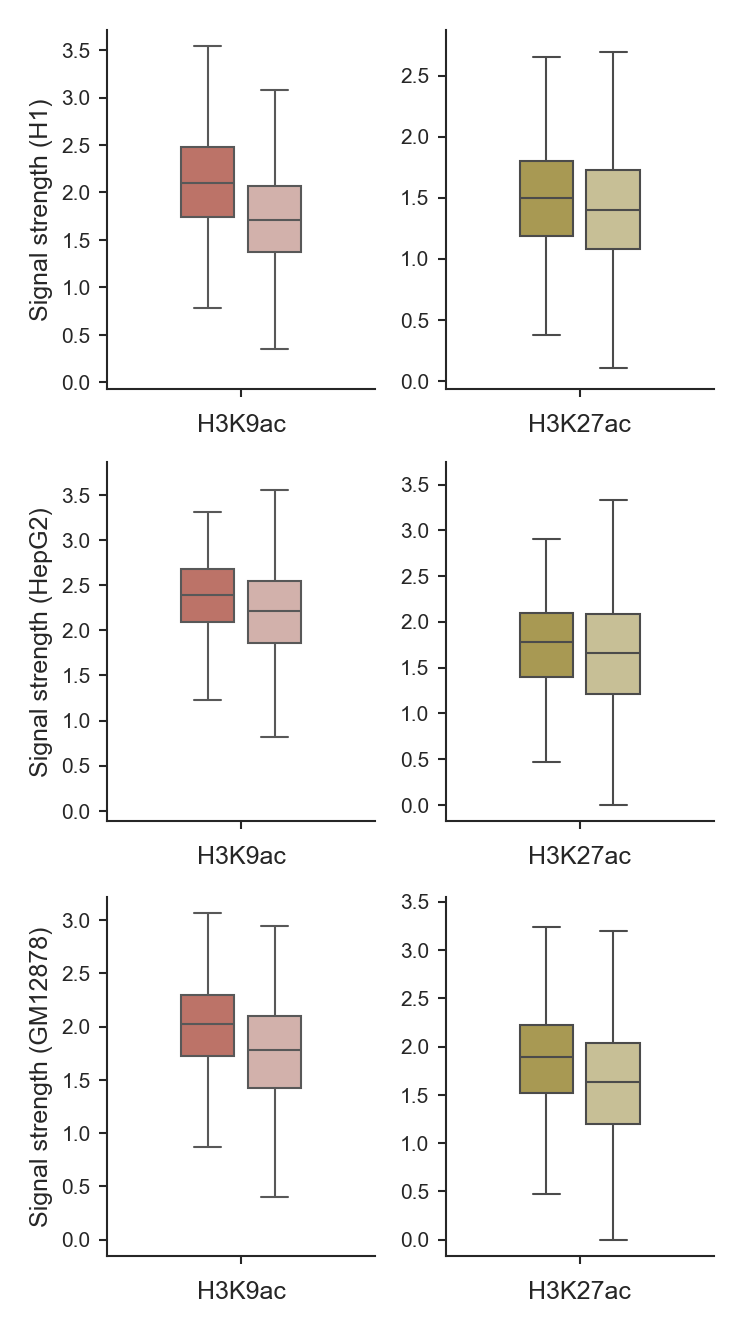

In [ ]:

MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac']
palette = {
    'H3K9ac':['#BC7368','#D2B1AB'],
    'H3K27ac':['#A89953','#C7BF96'],
    'H3K4me3':['#93A2B8','#BEC5D3'],
}


fig, ax = plt.subplots(3, 2, constrained_layout=True, figsize=(6/2.54, 11/2.54))

eid = 'E003'
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp'})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp'})
    data = pd.concat([data_1kbp,data_40kbp],axis=0)
    sns.boxplot(data=data, y='signal',hue='distance',
                palette=palette[mark],
            fliersize=0,
            linewidth=0.5,            
            ax=ax[0, idx % 3],
            saturation=1,
            width=0.5,
            gap=0.2
        )
    ax[0, idx % 3].legend().remove()
    ax[0, idx % 3].set_xlabel(mark, fontsize=6,fontweight='regular')
    ax[0, idx % 3].set_ylabel('', fontsize=6,fontweight='regular')
    # Set the xlabel for each subplot

ax[0,0].set_ylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)

eid = 'E118'
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp'})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp'})
    data = pd.concat([data_1kbp,data_40kbp],axis=0)
    sns.boxplot(data=data, y='signal',hue='distance',
                palette=palette[mark],
            fliersize=0,
            linewidth=0.5,            
            ax=ax[1, idx % 3],
            saturation=1,
            width=0.5,
            gap=0.2
        )
    ax[1, idx % 3].legend().remove()
    ax[1, idx % 3].set_xlabel(mark, fontsize=6,fontweight='regular')
    ax[1, idx % 3].set_ylabel('', fontsize=6,fontweight='regular')
    # Set the xlabel for each subplot

ax[1,0].set_ylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)


eid = 'E116'
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp'})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp'})
    data = pd.concat([data_1kbp,data_40kbp],axis=0)
    sns.boxplot(data=data, y='signal',hue='distance',
                palette=palette[mark],
            fliersize=0,
            linewidth=0.5,            
            ax=ax[2, idx % 3],
            saturation=1,
            width=0.5,
            gap=0.2
        )
    ax[2, idx % 3].legend().remove()
    ax[2, idx % 3].set_xlabel(mark, fontsize=6,fontweight='regular')
    ax[2, idx % 3].set_ylabel('', fontsize=6,fontweight='regular')
    # Set the xlabel for each subplot

ax[2,0].set_ylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)



import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette['H3K9ac'][0], label='H3K9ac Short-range genes'),
    mpatches.Patch(color=palette['H3K9ac'][1], label='H3K9ac Long-range genes'),

    mpatches.Patch(color=palette['H3K27ac'][0], label='H3K27ac Short-range genes'),
    mpatches.Patch(color=palette['H3K27ac'][1], label='H3K27ac Long-range genes'),

    # mpatches.Patch(color=palette['H3K4me3'][0], label='H3K4me3 Short-range genes'),
    # mpatches.Patch(color=palette['H3K4me3'][1], label='H3K4me3 Long-range genes'),
]
# legend = fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')
# for handle in legend.legend_handles:
#     if hasattr(handle, 'set_edgecolor'):
#         handle.set_edgecolor('none')  # 柱状色块边框
#     if hasattr(handle, 'set_linewidth'):
#         handle.set_linewidth(0)

# fig.supxlabel("Distance to TSS (kbp)",fontsize=6)


plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Supplementary_figure3A_2.eps', format='eps', bbox_inches='tight')

plt.show()


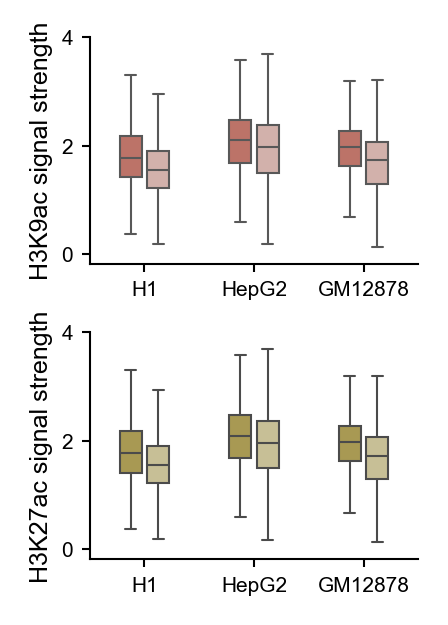

In [17]:

MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac']
palette = {
    'H3K9ac':['#BC7368','#D2B1AB'],
    'H3K27ac':['#A89953','#C7BF96'],
    'H3K4me3':['#93A2B8','#BEC5D3'],
}


fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(3.5/2.54, 5/2.54))

data = pd.DataFrame({})
eid = 'E003'
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

# Loop through the plots and plot the data without labels for legends

for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp','mark':mark,'eid':eid})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp','mark':mark,'eid':eid})
    data = pd.concat([data,data_1kbp,data_40kbp],axis=0)



eid = 'E118'
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp','mark':mark,'eid':eid})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp','mark':mark,'eid':eid})
    data = pd.concat([data,data_1kbp,data_40kbp],axis=0)



eid = 'E116'
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)



# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp','mark':mark,'eid':eid})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp','mark':mark,'eid':eid})
    data = pd.concat([data,data_1kbp,data_40kbp],axis=0)



order = ['E003','E118','E116']
xticklabels = [EIDS_TO_CELLTYPES[eid] for eid in order]
mark = 'H3K9ac'
sns.boxplot(data=data, x='eid', y='signal',hue='distance',
            palette=palette[mark],
            fliersize=0,
            linewidth=0.5,            
            ax=ax[0],
            saturation=1,
            width=0.5,
            gap=0.2,
            order=order
        )
ax[0].legend().remove()
ax[0].set_yticks([0,2,4])
ax[0].set_xticks(order,labels=xticklabels)
ax[0].set_xlabel('', fontsize=6,fontweight='regular')
ax[0].set_ylabel('', fontsize=6,fontweight='regular')
# Set the xlabel for each subplot

ax[0].set_ylabel(f"{mark} signal strength",fontsize=6)

mark = 'H3K27ac'
sns.boxplot(data=data, x='eid', y='signal',hue='distance',
            palette=palette[mark],
            fliersize=0,
            linewidth=0.5,            
            ax=ax[1],
            saturation=1,
            width=0.5,
            gap=0.2
        )

ax[1].legend().remove()
ax[1].set_yticks([0,2,4])
ax[1].set_xticks(order,labels=xticklabels)
ax[1].set_xlabel('', fontsize=6,fontweight='regular')
ax[1].set_ylabel('', fontsize=6,fontweight='regular')
# Set the xlabel for each subplot

ax[1].set_ylabel(f"{mark} signal strength",fontsize=6)
# import matplotlib.patches as mpatches
# legend_patches = [
#     mpatches.Patch(color=palette['H3K9ac'][0], label='H3K9ac Short-range genes'),
#     mpatches.Patch(color=palette['H3K9ac'][1], label='H3K9ac Long-range genes'),

#     mpatches.Patch(color=palette['H3K27ac'][0], label='H3K27ac Short-range genes'),
#     mpatches.Patch(color=palette['H3K27ac'][1], label='H3K27ac Long-range genes'),

#     # mpatches.Patch(color=palette['H3K4me3'][0], label='H3K4me3 Short-range genes'),
#     # mpatches.Patch(color=palette['H3K4me3'][1], label='H3K4me3 Long-range genes'),
# ]
# # legend = fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')
# # for handle in legend.legend_handles:
# #     if hasattr(handle, 'set_edgecolor'):
# #         handle.set_edgecolor('none')  # 柱状色块边框
# #     if hasattr(handle, 'set_linewidth'):
# #         handle.set_linewidth(0)

# # fig.supxlabel("Distance to TSS (kbp)",fontsize=6)


plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/figure3F.eps', format='eps', bbox_inches='tight')

plt.show()



In [148]:
data

,signal,distance,mark,eid
0,1.991474,1kbp,H3K9ac,E003
1,2.413230,1kbp,H3K9ac,E003
2,1.837518,1kbp,H3K9ac,E003
3,2.169680,1kbp,H3K9ac,E003
4,2.235019,1kbp,H3K9ac,E003
...,...,...,...,...
1754,2.023592,40kbp,H3K27ac,E116
1755,2.124874,40kbp,H3K27ac,E116
1756,2.114296,40kbp,H3K27ac,E116
1757,2.662066,40kbp,H3K27ac,E116


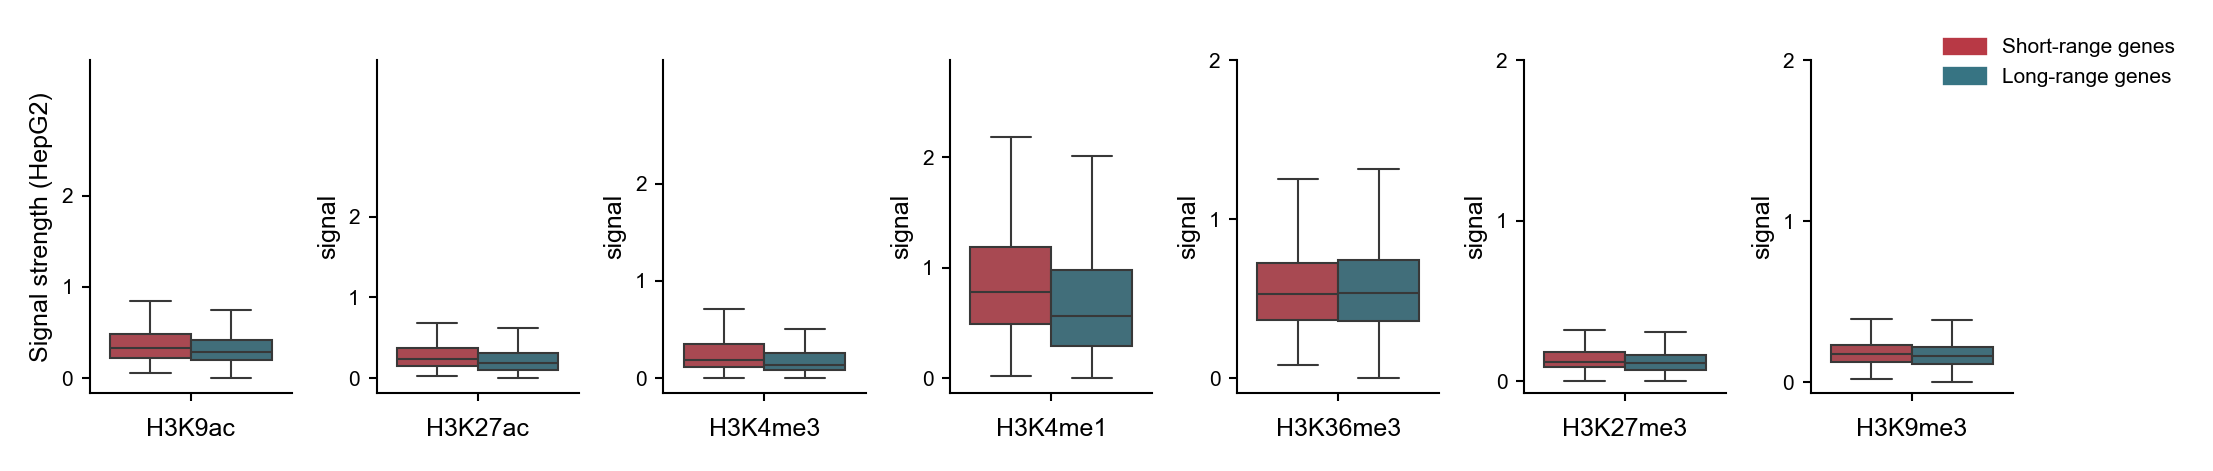

In [51]:

eid = 'E118'
palette = ["#B83945","#377483"]
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,48:52]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,48:52]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']


fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(17/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp'})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp'})
    data = pd.concat([data_1kbp,data_40kbp],axis=0)
    sns.boxplot(data=data, y='signal',hue='distance',
                palette=palette,
            fliersize=0,
            linewidth=0.5,            
            ax=ax[idx % 7],
        )
    ax[idx % 7].legend().remove()

    # ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    ax[idx % 7].set_xlabel(mark, fontsize=6,fontweight='regular')
    yticks = [i for i in range(0, 3, 1)]
    ax[idx % 7].set_yticks(yticks)

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='Short-range genes'),
    mpatches.Patch(color=palette[1], label='Long-range genes'),
]
fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

# fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
ax[0].set_ylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)

# plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v5/Supplementary_figure4H_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


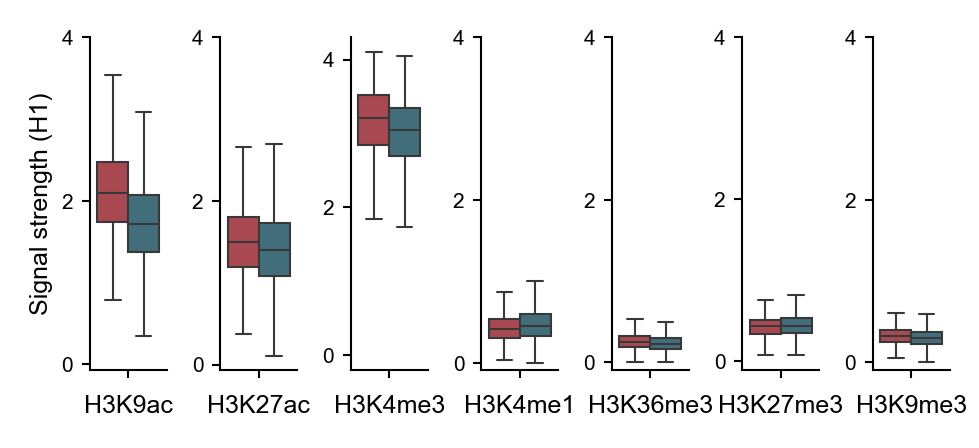

In [57]:

eid = 'E003'
palette = ["#B83945","#377483"]
mark_signals_1kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']


fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(8/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp'})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp'})
    data = pd.concat([data_1kbp,data_40kbp],axis=0)
    sns.boxplot(data=data, y='signal',hue='distance',
                palette=palette,
            fliersize=0,
            linewidth=0.5,            
            ax=ax[idx % 7],
        )
    ax[idx % 7].legend().remove()

    # ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    ax[idx % 7].set_xlabel(mark, fontsize=6,fontweight='regular')
    yticks = [i for i in range(0, 5, 2)]
    ax[idx % 7].set_yticks(yticks)
    ax[idx % 7].set_ylabel(f"",fontsize=6)
    # Set the xlabel for each subplot

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='Short-range genes'),
    mpatches.Patch(color=palette[1], label='Long-range genes'),
]
# fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

# fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
ax[0].set_ylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Figure3H_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


# motif analysis

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_49669/3471903309.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['TATA','Inr','CCAAT','GCbox'],ha='center',fontsize=5)


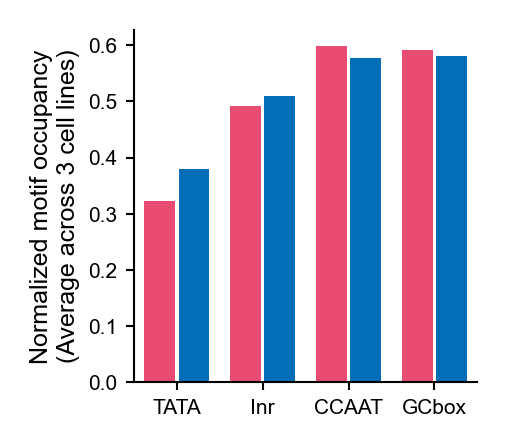

In [23]:
motif_indicatores = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_motif_indicators_pred.csv')
motif_indicatores
palette = ['#E94C72','#036EB8']
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4/2.54, 3.5/2.54))
hue_order = ['bf_label_pred','bs_label_pred']
sns.barplot(data=motif_indicatores,x='motif',y='ratio',hue='target',palette=palette,
            linewidth=0.0,            
            ax=ax,
            saturation=1,
            width=0.8,
            gap=0.1,
            hue_order=hue_order,
        )


ax.set_xticklabels(['TATA','Inr','CCAAT','GCbox'],ha='center',fontsize=5)
ax.legend().remove()
ax.set_xlabel('', fontsize=6,fontweight='regular')
ax.set_ylabel('Normalized motif occupancy\n(Average across 3 cell lines)', fontsize=6,fontweight='regular')
legend_patches = [
    mpatches.Patch(color=palette[0], label='BF+'),
    mpatches.Patch(color=palette[1], label='BS+'),
]
# fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Figure4F.eps', format='eps', bbox_inches='tight')
plt.show()

# pCREs 分析

T-test p = 0.000e+00
     region_type      mean       std  count       sem
0      attention  0.508485  0.252815  22299  0.001693
1  non_attention  0.201331  0.151467  62435  0.000606


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_38268/2553849635.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=agg_overlap, x="cres_density", y="region_type", palette=["#E64B35","#4DBBD5"],
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_38268/2553849635.py:41: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(data=agg_overlap, x="cres_density", y="region_type", palette=["#E64B35","#4DBBD5"],
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_38268/2553849635.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["High-Attention regions", "Low-attention regions"])


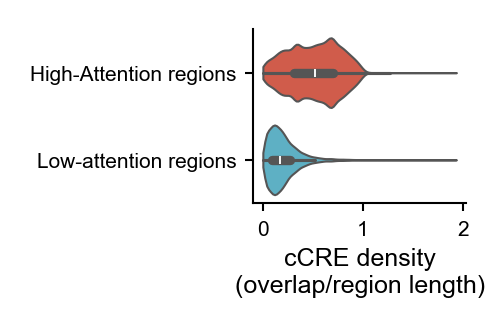

T-test p = 0.000e+00


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 读取你的结果表
df = pd.read_csv("extra/datasets/benchmark/Promoterformer/attention_overlap_E116.csv")

# ---- 计算每个区域的长度 ----
df["region_length"] = df["region_end"] - df["region_start"]

# ---- 对每条 (gene_id, region_type) 汇总 ----
# 先计算每个区域的总 overlap 长度
agg_overlap = (
    df.groupby(["gene_id", "region_type", "region_start", "region_end"], as_index=False)
      .agg(overlap_length=("overlap_length", "sum"),
           region_length=("region_end", lambda x: x.iloc[0] - df.loc[x.index[0], "region_start"]))
)
agg_overlap["cres_density"] = agg_overlap["overlap_length"] / agg_overlap["region_length"]

# ---- 两组数据 ----
att = agg_overlap.query("region_type == 'attention'")["cres_density"].dropna()
non = agg_overlap.query("region_type == 'non_attention'")["cres_density"].dropna()

# ---- t-test ----
stat, pval = ttest_ind(att, non, equal_var=False)
print(f"T-test p = {pval:.3e}")


# ---- 按 region_type 统计平均密度 ----
summary = (
    agg_overlap.groupby("region_type")["cres_density"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["sem"] = summary["std"] / np.sqrt(summary["count"])
print(summary)

# ---- 可视化 ----
plt.figure(figsize=(4.5/2.54, 3/2.54))
ax = sns.violinplot(data=agg_overlap, x="cres_density", y="region_type", palette=["#E64B35","#4DBBD5"], 
                    linewidth=0.5,
    cut=0,               scale="width")       # 按组宽度缩放)
# sns.stripplot(data=agg_overlap, x="region_type", y="cres_density", color="black", size=1.5, alpha=0.3)
ax.set_xlabel("cCRE density\n(overlap/region length)")
ax.set_ylabel("")
ax.set_yticklabels(["High-Attention regions", "Low-attention regions"])
# ax.set_title("Enrichment of cCREs in attention vs non-attention regions")

plt.tight_layout()
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Figure4F.eps', format='eps', bbox_inches='tight')
plt.show()

# ---- 统计显著性检验 ----
from scipy.stats import ttest_ind

att = agg_overlap.loc[agg_overlap["region_type"]=="attention","cres_density"].dropna()
non = agg_overlap.loc[agg_overlap["region_type"]=="non_attention","cres_density"].dropna()
stat, pval = ttest_ind(att, non, equal_var=False)
print(f"T-test p = {pval:.3e}")

In [21]:
def summarize_overlap(df):
    summary_gene = df.groupby('gene_id')['cres_id'].count().reset_index(name='n_overlaps')
    summary_type = df['cres_type'].value_counts(normalize=True).rename_axis('cres_type').reset_index(name='percent')

    print(f"✅ Total genes: {len(summary_gene)}, total overlaps: {len(df)}")
    print("Top cCRE types:")
    print(summary_type.head(10))

    return summary_gene, summary_type

In [22]:
summarize_overlap(df[df['region_type']=='attention'])

✅ Total genes: 12526, total overlaps: 44457
Top cCRE types:
                  cres_type   percent
0           pELS,CTCF-bound  0.365634
1                      pELS  0.219965
2                      dELS  0.145241
3            PLS,CTCF-bound  0.115572
4           dELS,CTCF-bound  0.112761
5                       PLS  0.022966
6             DNase-H3K4me3  0.006928
7      CTCF-only,CTCF-bound  0.006388
8  DNase-H3K4me3,CTCF-bound  0.004544


(               gene_id  n_overlaps
 0      ENSG00000000003           7
 1      ENSG00000000005           1
 2      ENSG00000000419           2
 3      ENSG00000000457           2
 4      ENSG00000000938           2
 ...                ...         ...
 12521  ENSG00000259458           2
 12522  ENSG00000259471           2
 12523  ENSG00000259517           4
 12524  ENSG00000259518           2
 12525  ENSG00000259717           9
 
 [12526 rows x 2 columns],
                   cres_type   percent
 0           pELS,CTCF-bound  0.365634
 1                      pELS  0.219965
 2                      dELS  0.145241
 3            PLS,CTCF-bound  0.115572
 4           dELS,CTCF-bound  0.112761
 5                       PLS  0.022966
 6             DNase-H3K4me3  0.006928
 7      CTCF-only,CTCF-bound  0.006388
 8  DNase-H3K4me3,CTCF-bound  0.004544)

In [26]:
df1 = df[df['region_type']=='attention']
summary_type = df1['cres_type'].value_counts(normalize=True).rename_axis('cres_type').reset_index(name='percent')

In [27]:
summary_type['cres_type'] = summary_type.apply(lambda row: row['cres_type'] if row['percent'] > 0.1 else 'Other', axis=1)
summary_type = (
    summary_type.groupby("cres_type", as_index=False)["percent"]
    .sum()
    .sort_values("percent", ascending=False)
    .reset_index(drop=True)
)

summary_type

,cres_type,percent
0,"pELS,CTCF-bound",0.365634
1,pELS,0.219965
2,dELS,0.145241
3,"PLS,CTCF-bound",0.115572
4,"dELS,CTCF-bound",0.112761
5,Other,0.040826


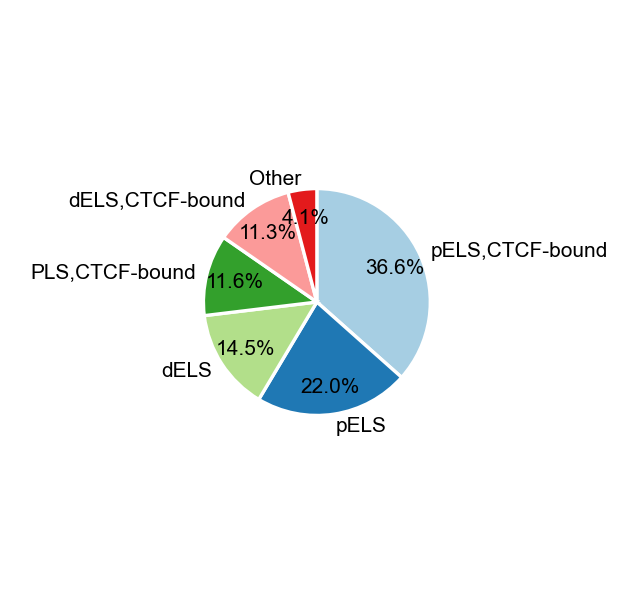

In [36]:
import matplotlib.pyplot as plt
import pandas as pd



# 按比例排序（从大到小）
summary_type = summary_type.sort_values("percent", ascending=False)

# 颜色方案（柔和、互补）
colors = plt.cm.Paired(range(len(summary_type)))

# 绘制饼图
fig, ax = plt.subplots(figsize=(5.5/2.54, 5.5/2.54))  # 6 cm × 6 cm
wedges, texts, autotexts = ax.pie(
    summary_type["percent"],
    labels=summary_type["cres_type"],
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",  # 小于1%不显示
    pctdistance=0.75,
    textprops={'fontsize': 5, 'color': 'black'},
    startangle=90,  # 使最大扇区在顶部
    counterclock=False
)

# 美化细节
for t in autotexts:
    t.set_fontsize(5)
# ax.set_title("cCRE composition in attention regions", fontsize=7, pad=4)
ax.axis('equal')  # 保持圆形

# 去掉边框
plt.tight_layout()
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/v6/Figure4F_2.eps', format='eps', bbox_inches='tight')
plt.show()
